In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

## Import Dataset and Basic Cleaning 

In [2]:
df = pd.read_csv('air_quality_health_dataset.csv')
df

,date,region,AQI,PM2.5,PM10,NO2,SO2,CO,O3,temperature,...,school_closures,public_transport_usage,mask_usage_rate,lockdown_status,industrial_activity,vehicle_count,construction_activity,respiratory_admissions,population_density,green_cover_percentage
0,2020-01-01,East,109.934283,31.382887,57.718373,47.654022,25.874070,0.956973,32.574682,37.555663,...,0,43.103376,75.706162,0,66.098466,9757,63.001573,11,1957.637287,42.348419
1,2020-01-02,Central,97.234714,47.094225,67.381383,50.734127,10.605095,0.990203,23.749138,24.900342,...,0,30.606591,69.652802,0,107.686174,9157,6.417798,13,2962.769470,27.712735
2,2020-01-03,East,112.953771,53.795917,61.158796,44.986899,18.361025,1.019288,35.530851,23.437165,...,0,13.037424,82.561183,1,77.445192,2058,66.001849,3,6912.007043,41.031516
3,2020-01-04,West,130.460597,88.315315,69.040084,20.575023,19.791700,1.284058,25.277106,22.388200,...,0,8.974779,73.642836,0,51.864000,8726,79.580923,6,9227.543628,40.543537
4,2020-01-05,South,95.316933,68.348297,75.716994,38.445776,20.079543,0.775835,35.996440,26.881835,...,1,96.022689,68.688106,0,148.714488,9720,6.301105,8,1277.810175,5.648920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2020-03-16,West,101.549610,62.572040,82.032601,28.188065,15.451740,1.295485,26.473666,30.823665,...,0,6.268495,79.924698,0,63.894720,9727,17.517691,8,6376.519945,12.957398
2996,2020-03-17,Central,105.155051,77.289722,103.344355,39.271776,26.185755,0.765007,41.684453,28.343987,...,0,21.483037,76.189034,0,115.253298,7571,10.698859,7,2895.955761,46.956454
2997,2020-03-18,East,75.164788,41.738943,111.768944,48.380141,26.561040,1.235577,39.295269,26.050318,...,0,93.894493,60.866306,0,57.151724,1497,42.777210,10,8137.193349,18.919346
2998,2020-03-19,Central,106.683528,67.019256,66.300256,38.993041,15.579454,0.655209,31.667658,26.028273,...,0,73.990617,91.471722,0,66.552816,3412,1.218238,11,8997.326165,25.754999


In [3]:
'''
Basic Identifiers
. date → Daily timestamp (convert to datetime)
. region → Geographic area (categorical: East, West, etc.)

Air Pollution Indicators
These are your core independent variables:
. AQI → Air Quality Index (overall pollution score)
. PM2.5 → Fine particles (most harmful, enters lungs)
. PM10 → Coarser particles
. NO2 → Nitrogen dioxide (traffic pollution)
. SO2 → Sulfur dioxide (industrial pollution)
. CO → Carbon monoxide (incomplete combustion)
. O3 → Ozone (secondary pollutant)

Weather Factors
These affect pollution dispersion:
. temperature
. humidity
. wind_speed
. precipitation

Health Impact Metrics
Your target variables (very important):
. hospital_visits → General hospital visits
. emergency_visits → Urgent cases
. respiratory_admissions → Direct pollution-related cases

Human Behavior / Policy Variables
. mobility_index → Movement of people
. school_closures → 0/1 indicator
. public_transport_usage
. mask_usage_rate
. lockdown_status → 0/1

Activity Indicators (pollution sources)
. industrial_activity
. vehicle_count
. construction_activity

Environmental Context
. population_density
. green_cover_percentage
'''

'\nBasic Identifiers\n. date → Daily timestamp (convert to datetime)\n. region → Geographic area (categorical: East, West, etc.)\n\nAir Pollution Indicators\nThese are your core independent variables:\n. AQI → Air Quality Index (overall pollution score)\n. PM2.5 → Fine particles (most harmful, enters lungs)\n. PM10 → Coarser particles\n. NO2 → Nitrogen dioxide (traffic pollution)\n. SO2 → Sulfur dioxide (industrial pollution)\n. CO → Carbon monoxide (incomplete combustion)\n. O3 → Ozone (secondary pollutant)\n\nWeather Factors\nThese affect pollution dispersion:\n. temperature\n. humidity\n. wind_speed\n. precipitation\n\nHealth Impact Metrics\nYour target variables (very important):\n. hospital_visits → General hospital visits\n. emergency_visits → Urgent cases\n. respiratory_admissions → Direct pollution-related cases\n\nHuman Behavior / Policy Variables\n. mobility_index → Movement of people\n. school_closures → 0/1 indicator\n. public_transport_usage\n. mask_usage_rate\n. lockdown_

In [4]:
df.shape

(3000, 26)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    3000 non-null   str    
 1   region                  3000 non-null   str    
 2   AQI                     3000 non-null   float64
 3   PM2.5                   3000 non-null   float64
 4   PM10                    3000 non-null   float64
 5   NO2                     3000 non-null   float64
 6   SO2                     3000 non-null   float64
 7   CO                      3000 non-null   float64
 8   O3                      3000 non-null   float64
 9   temperature             3000 non-null   float64
 10  humidity                3000 non-null   float64
 11  wind_speed              3000 non-null   float64
 12  precipitation           3000 non-null   float64
 13  hospital_visits         3000 non-null   int64  
 14  emergency_visits        3000 non-null   int64  
 15

In [6]:
df.describe()

,AQI,PM2.5,PM10,NO2,SO2,CO,O3,temperature,humidity,wind_speed,...,school_closures,public_transport_usage,mask_usage_rate,lockdown_status,industrial_activity,vehicle_count,construction_activity,respiratory_admissions,population_density,green_cover_percentage
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,100.640017,59.426348,80.062682,39.789545,20.173112,1.005489,29.970248,24.950278,55.064617,7.445412,...,0.092667,50.097325,75.081933,0.143667,100.544391,5453.904000,49.107961,9.923333,4981.290570,37.367668
std,19.736152,15.132393,20.522269,9.834362,5.011277,0.301906,8.026695,4.927167,20.336369,4.296773,...,0.290013,28.678922,14.375187,0.350810,29.058113,2564.332936,29.179745,3.161031,2821.503566,18.837611
min,35.174653,12.349443,3.266889,0.775997,3.352481,0.000000,0.000000,6.724567,20.004725,0.000083,...,0.000000,0.015119,50.006501,0.000000,50.044362,1005.000000,0.012882,1.000000,100.290565,5.011603
25%,87.449177,49.311574,66.028068,33.279636,16.761137,0.799757,24.590968,21.484840,36.896629,3.705526,...,0.000000,25.545471,62.458830,0.000000,74.893268,3256.500000,23.137463,8.000000,2549.128743,20.919710
50%,100.487296,59.665656,79.683829,39.771488,20.186704,1.008749,29.940792,24.947689,55.411279,7.479178,...,0.000000,49.583222,75.528614,0.000000,100.895015,5437.000000,49.107590,10.000000,4960.964843,37.615476
75%,113.471818,69.579966,94.064564,46.332485,23.524396,1.212121,35.551940,28.309660,72.455010,11.083132,...,0.000000,75.364285,87.375068,0.000000,126.249572,7629.000000,74.858781,12.000000,7408.607572,53.441531
max,178.524754,108.646395,150.581104,73.777682,37.144552,2.343725,61.538648,43.056750,89.978805,14.996841,...,1.000000,99.975223,99.990897,1.000000,149.985847,9998.000000,99.975422,23.000000,9998.642584,69.936634


In [7]:
df.columns

Index(['date', 'region', 'AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3',
       'temperature', 'humidity', 'wind_speed', 'precipitation',
       'hospital_visits', 'emergency_visits', 'mobility_index',
       'school_closures', 'public_transport_usage', 'mask_usage_rate',
       'lockdown_status', 'industrial_activity', 'vehicle_count',
       'construction_activity', 'respiratory_admissions', 'population_density',
       'green_cover_percentage'],
      dtype='str')

In [8]:
df.isnull().sum()

date                      0
region                    0
AQI                       0
PM2.5                     0
PM10                      0
NO2                       0
SO2                       0
CO                        0
O3                        0
temperature               0
humidity                  0
wind_speed                0
precipitation             0
hospital_visits           0
emergency_visits          0
mobility_index            0
school_closures           0
public_transport_usage    0
mask_usage_rate           0
lockdown_status           0
industrial_activity       0
vehicle_count             0
construction_activity     0
respiratory_admissions    0
population_density        0
green_cover_percentage    0
dtype: int64

In [9]:
'''These are no null values in any columns'''

'These are no null values in any columns'

## 1. Pollution Analysis

In [10]:
# 1. Which pollutant contributes most to AQI?
df[['AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']].corr()['AQI']

AQI      1.000000
PM2.5   -0.009779
PM10     0.009245
NO2      0.011191
SO2     -0.021223
CO      -0.002879
O3       0.000786
Name: AQI, dtype: float64

<Axes: >

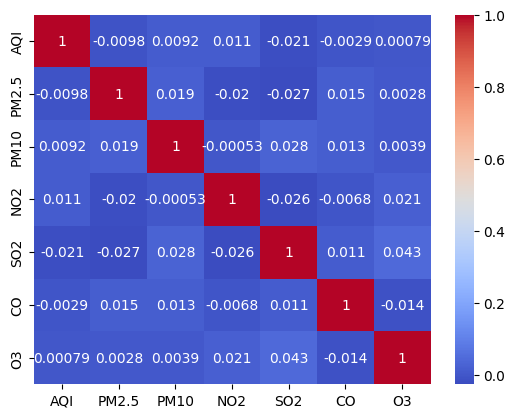

In [11]:
sns.heatmap(
    df[['AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']].corr(),
    cmap='coolwarm',
    annot=True
)

In [12]:
'''“The correlation analysis shows that AQI has negligible linear relationships with individual pollutants (all coefficients ≈ 0). This suggests that AQI is either derived using a non-linear or composite formula, or that individual pollutants alone do not explain AQI variation in this dataset.”'''

'“The correlation analysis shows that AQI has negligible linear relationships with individual pollutants (all coefficients ≈ 0). This suggests that AQI is either derived using a non-linear or composite formula, or that individual pollutants alone do not explain AQI variation in this dataset.”'

In [13]:
# 2. Which region has the worst air quality?
df.groupby('region')['AQI'].mean()

region
Central     99.294617
East       102.739112
North       99.241155
South      100.195015
West       101.563788
Name: AQI, dtype: float64

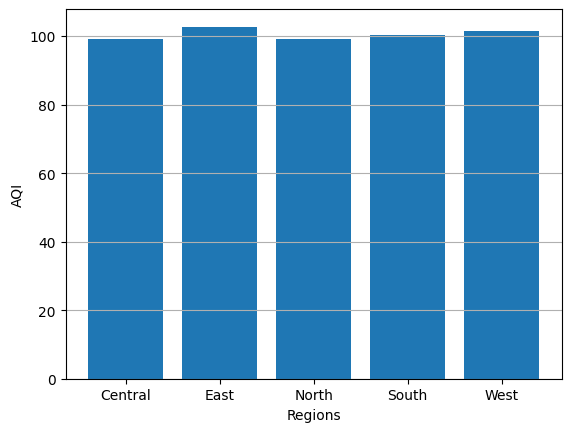

In [14]:
plt.bar(df.groupby('region')['AQI'].mean().index, df.groupby('region')['AQI'].mean().values)
plt.xlabel('Regions')
plt.ylabel('AQI')
plt.grid(axis = 'y')

In [15]:
'''
The bar chart shows that AQI levels are fairly consistent across all regions, ranging roughly between 99 and 103, indicating minimal variation in air quality geographically. The East region records the highest AQI, while Central and North have slightly lower values, but the differences are marginal and not significant enough to suggest any region is substantially more polluted than others. This uniformity implies that air pollution in the dataset is evenly distributed across regions, and regional location alone does not play a major role in influencing AQI levels.
'''

'\nThe bar chart shows that AQI levels are fairly consistent across all regions, ranging roughly between 99 and 103, indicating minimal variation in air quality geographically. The East region records the highest AQI, while Central and North have slightly lower values, but the differences are marginal and not significant enough to suggest any region is substantially more polluted than others. This uniformity implies that air pollution in the dataset is evenly distributed across regions, and regional location alone does not play a major role in influencing AQI levels.\n'

In [16]:
# 3. Seasonal trend of AQI (monthly avg)?
df['date'] = pd.to_datetime(df['date'])

In [17]:
df['Month'] = df['date'].dt.month

In [18]:
df.groupby('Month')['AQI'].mean()

Month
1     100.243881
2     101.353189
3     100.285380
4      99.710816
5     101.623785
6     102.076872
7     100.216598
8      99.966165
9      99.749813
10    101.784523
11    100.096921
12    100.593890
Name: AQI, dtype: float64

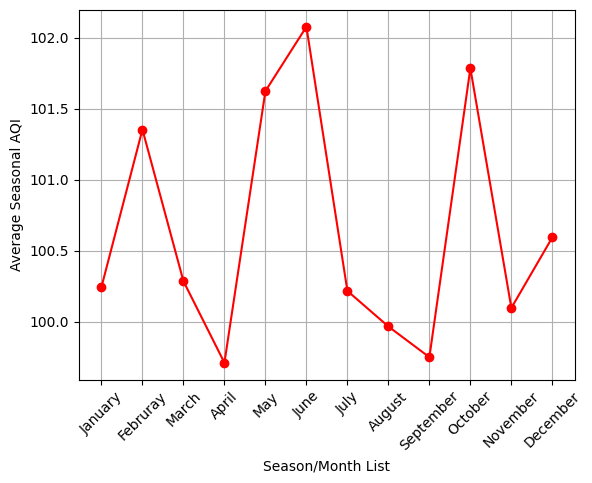

In [19]:
plt.plot(df.groupby('Month')['AQI'].mean().index, df.groupby('Month')['AQI'].mean().values, marker = 'o', color = 'red')
plt.xlabel('Season/Month List')
plt.ylabel('Average Seasonal AQI')
plt.xticks(
    ticks = df.groupby('Month')['AQI'].mean().index,
    labels=['January', 'Februray', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'],
    rotation=45
)
plt.grid()

In [20]:
'''
The line plot shows that average AQI remains relatively stable throughout the year, fluctuating within a narrow range of approximately 99.7 to 102.1. A noticeable peak occurs in June, indicating slightly higher pollution levels during early summer, followed by another rise in October. In contrast, the lowest AQI values are observed around April and September, suggesting comparatively better air quality during these periods. However, the overall variation is minimal, indicating that seasonal changes do not have a significant impact on AQI in this dataset. This suggests that factors other than seasonal variation—such as human activities or localized conditions—may play a more dominant role in influencing air quality.
'''

'\nThe line plot shows that average AQI remains relatively stable throughout the year, fluctuating within a narrow range of approximately 99.7 to 102.1. A noticeable peak occurs in June, indicating slightly higher pollution levels during early summer, followed by another rise in October. In contrast, the lowest AQI values are observed around April and September, suggesting comparatively better air quality during these periods. However, the overall variation is minimal, indicating that seasonal changes do not have a significant impact on AQI in this dataset. This suggests that factors other than seasonal variation—such as human activities or localized conditions—may play a more dominant role in influencing air quality.\n'

## 2. Weather vs Pollution

In [21]:
# 1. Does higher wind speed reduce AQI?
bins = [8, 10, 12, 14, 16]
labels = ['Light Breeze', 'Moderate Breeze', 'Strong Breeze', 'High Wind']
df['wind_speed_bins'] = pd.cut(df['wind_speed'], bins=bins, labels=labels)

In [22]:
df.groupby('wind_speed_bins')['AQI'].mean().sort_values(ascending=False)

wind_speed_bins
High Wind          102.375775
Light Breeze       101.282205
Strong Breeze      100.095660
Moderate Breeze     99.606492
Name: AQI, dtype: float64

In [23]:
'''
While moderate wind speeds are associated with slightly better air quality, the inconsistent trend across categories indicates that wind speed is not a strong standalone determinant of AQI in this dataset.
'''

'\nWhile moderate wind speeds are associated with slightly better air quality, the inconsistent trend across categories indicates that wind speed is not a strong standalone determinant of AQI in this dataset.\n'

In [24]:
# 2. Relationship between humidity and PM2.5?
bins = [20, 40, 60, 80, 100]
labels = ['Dry', 'Moderate', 'Humid', 'Very Humid']

df['humidity_bins'] = pd.cut(df['humidity'], bins=bins, labels=labels)
df.groupby('humidity_bins')['PM2.5'].mean()

humidity_bins
Dry           59.273110
Moderate      59.696752
Humid         59.655150
Very Humid    58.756093
Name: PM2.5, dtype: float64

<Axes: xlabel='humidity_bins', ylabel='PM2.5'>

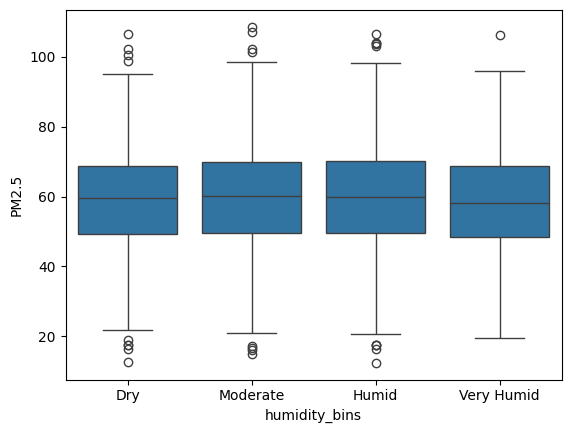

In [25]:
sns.boxplot(x = 'humidity_bins', y = 'PM2.5', data=df)

In [26]:
'''
The boxplot shows that PM2.5 levels remain relatively consistent across different humidity categories, with similar medians and spread. There is no clear trend indicating that increasing or decreasing humidity significantly affects PM2.5 concentrations. This suggests that humidity alone is not a strong determinant of particulate matter levels in this dataset, and other factors likely play a more dominant role.
'''

'\nThe boxplot shows that PM2.5 levels remain relatively consistent across different humidity categories, with similar medians and spread. There is no clear trend indicating that increasing or decreasing humidity significantly affects PM2.5 concentrations. This suggests that humidity alone is not a strong determinant of particulate matter levels in this dataset, and other factors likely play a more dominant role.\n'

<Axes: xlabel='precipitation', ylabel='AQI'>

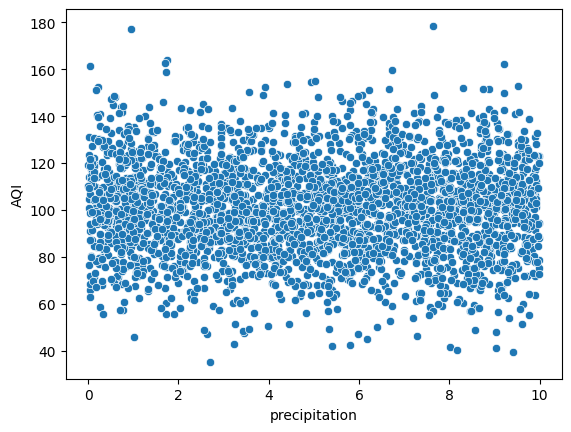

In [27]:
# 3. Does rainfall reduce pollution levels?
sns.scatterplot(x = 'precipitation', y = 'AQI', data = df)

In [28]:
# since there is no clear evidence of AQI and Precipitation from the above scatter plot, we can try finding using bins and correlation

In [29]:
df[['precipitation', 'AQI']].corr()

,precipitation,AQI
precipitation,1.000000,-0.019581
AQI,-0.019581,1.000000


In [30]:
'''
The correlation analysis shows a very weak negative relationship (-0.0196) between precipitation and AQI, indicating that while rainfall may have a slight tendency to reduce pollution levels, its impact is negligible in this dataset. This suggests that precipitation alone is not a strong determinant of air quality
'''

'\nThe correlation analysis shows a very weak negative relationship (-0.0196) between precipitation and AQI, indicating that while rainfall may have a slight tendency to reduce pollution levels, its impact is negligible in this dataset. This suggests that precipitation alone is not a strong determinant of air quality\n'

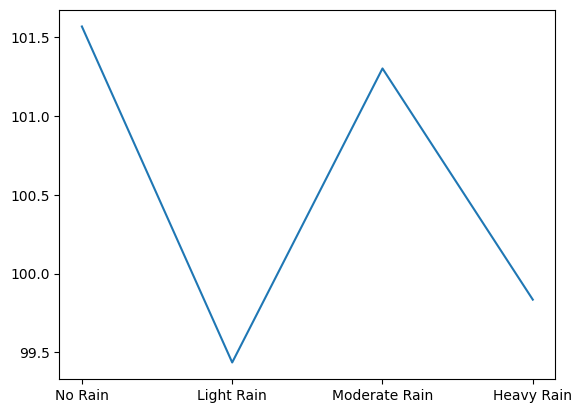

In [31]:
bins = [0, 3, 5, 7, 9]
labels = ['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain']

df['precipitation_bins'] = pd.cut(df['precipitation'], bins=bins, labels=labels)
plt.plot(df.groupby('precipitation_bins')['AQI'].mean().index, df.groupby('precipitation_bins')['AQI'].mean().values)

In [32]:
'''
Although light rainfall appears to reduce AQI, the fluctuating pattern across higher rainfall levels indicates that precipitation alone is not a strong or consistent factor influencing air quality in this dataset.
'''

'\nAlthough light rainfall appears to reduce AQI, the fluctuating pattern across higher rainfall levels indicates that precipitation alone is not a strong or consistent factor influencing air quality in this dataset.\n'

## 3. Health Impact Analysis

In [33]:
# 1. Does AQI correlate with hospital visits?
df[['AQI', 'hospital_visits']].corr()

,AQI,hospital_visits
AQI,1.000000,0.008556
hospital_visits,0.008556,1.000000


In [34]:
'''
The correlation between AQI and hospital visits is extremely weak (0.0086), indicating that AQI does not have a significant direct linear impact on hospital visits in this dataset. This suggests that health outcomes may be influenced by more complex factors, including specific pollutants or delayed effects, rather than AQI alone.
'''

'\nThe correlation between AQI and hospital visits is extremely weak (0.0086), indicating that AQI does not have a significant direct linear impact on hospital visits in this dataset. This suggests that health outcomes may be influenced by more complex factors, including specific pollutants or delayed effects, rather than AQI alone.\n'

<Axes: >

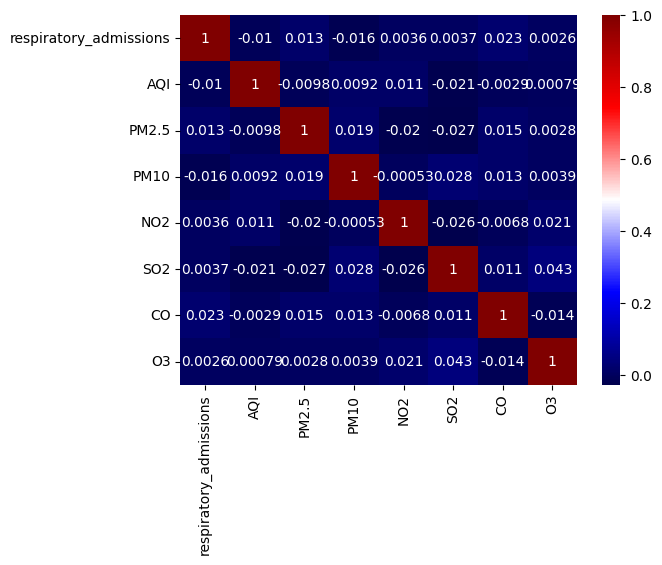

In [35]:
# 2. Which pollutant has the strongest impact on respiratory admissions?
sns.heatmap(
    df[['respiratory_admissions', 'AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']].corr(),
    cmap='seismic',
    annot=True
)

In [36]:
'''
The correlation analysis shows that none of the pollutants have a significant linear relationship with respiratory admissions, as all correlation coefficients are close to zero. Although CO exhibits the highest positive correlation, its impact is negligible, indicating that respiratory health outcomes in this dataset are not strongly explained by individual pollutant levels alone.
'''

'\nThe correlation analysis shows that none of the pollutants have a significant linear relationship with respiratory admissions, as all correlation coefficients are close to zero. Although CO exhibits the highest positive correlation, its impact is negligible, indicating that respiratory health outcomes in this dataset are not strongly explained by individual pollutant levels alone.\n'

In [37]:
# 3. Is there a lag effect? (pollution today → hospital tomorrow)
df = df.sort_values(by=['region', 'date'])

In [38]:
df['AQI_Lag'] = df.groupby('region')['AQI'].shift(1)
df[['AQI_Lag', 'hospital_visits']].corr()

,AQI_Lag,hospital_visits
AQI_Lag,1.00000,0.00369
hospital_visits,0.00369,1.00000


In [39]:
'''
The lag analysis shows an extremely weak correlation (0.0037) between previous day AQI and hospital visits, indicating no significant delayed effect of air pollution on hospital admissions in this dataset. This suggests that short-term lagged AQI alone is not a reliable predictor of healthcare demand.
'''

'\nThe lag analysis shows an extremely weak correlation (0.0037) between previous day AQI and hospital visits, indicating no significant delayed effect of air pollution on hospital admissions in this dataset. This suggests that short-term lagged AQI alone is not a reliable predictor of healthcare demand.\n'

In [43]:
# in case of lagging a bit more times to see if it makes any difference
for lag in [3, 4, 5]:
    df[f'AQI_lag{lag}'] = df.groupby('region')['AQI'].shift(lag)

In [45]:
df[[f'AQI_lag{lag}' for lag in [3, 4, 5]] + ['hospital_visits']].corr()

,AQI_lag3,AQI_lag4,AQI_lag5,hospital_visits
AQI_lag3,1.000000,-0.027746,0.012003,-0.026995
AQI_lag4,-0.027746,1.000000,-0.026039,-0.007162
AQI_lag5,0.012003,-0.026039,1.000000,0.022818
hospital_visits,-0.026995,-0.007162,0.022818,1.000000


In [46]:
'''
The correlations between lagged AQI (3–5 days) and hospital visits are:
. Lag 3 → -0.0270 (very weak negative)
. Lag 4 → -0.0072 (negligible)
. Lag 5 → 0.0228 (very weak positive)
'''

'\nThe correlations between lagged AQI (3–5 days) and hospital visits are:\n. Lag 3 → -0.0270 (very weak negative)\n. Lag 4 → -0.0072 (negligible)\n. Lag 5 → 0.0228 (very weak positive)\n'

## 4. Human Activity Impact

In [47]:
# 1. Does higher vehicle_count increase NO2 or CO?
df[['vehicle_count', 'NO2', 'CO']].corr()

,vehicle_count,NO2,CO
vehicle_count,1.000000,0.002264,0.000452
NO2,0.002264,1.000000,-0.006825
CO,0.000452,-0.006825,1.000000


In [48]:
'''
The correlation analysis shows that vehicle count has an extremely weak relationship with both NO2 (0.0023) and CO (0.00045), indicating that vehicle activity does not significantly influence these pollutants in this dataset. This suggests that other factors, such as industrial emissions or environmental conditions, may play a more dominant role.
'''

'\nThe correlation analysis shows that vehicle count has an extremely weak relationship with both NO2 (0.0023) and CO (0.00045), indicating that vehicle activity does not significantly influence these pollutants in this dataset. This suggests that other factors, such as industrial emissions or environmental conditions, may play a more dominant role.\n'

In [57]:
# 2. Relationship between industrial_activity and SO2?
df[['industrial_activity', 'SO2']].corr()

,industrial_activity,SO2
industrial_activity,1.000000,0.016686
SO2,0.016686,1.000000


<Axes: xlabel='industrial_activity', ylabel='SO2'>

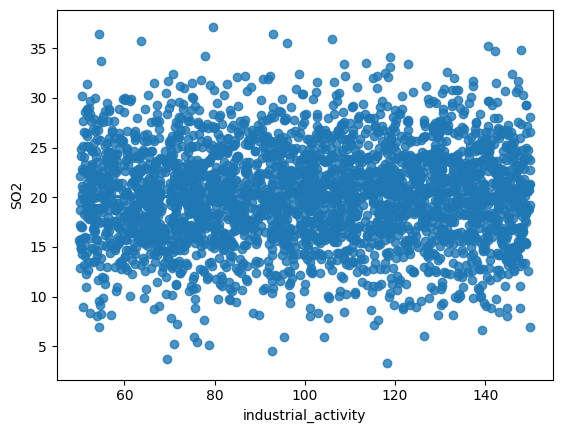

In [55]:
sns.regplot(x='industrial_activity', y='SO2', data=df)

In [58]:
'''
The analysis shows an extremely weak correlation (0.0167) between industrial activity and SO₂ levels, supported by the scatter plot which exhibits no clear trend. This indicates that industrial activity does not have a significant direct impact on SO₂ concentrations in this dataset. The lack of a visible pattern suggests that other factors may be more influential in determining SO₂ levels.
'''

'\nThe analysis shows an extremely weak correlation (0.0167) between industrial activity and SO₂ levels, supported by the scatter plot which exhibits no clear trend. This indicates that industrial activity does not have a significant direct impact on SO₂ concentrations in this dataset. The lack of a visible pattern suggests that other factors may be more influential in determining SO₂ levels.\n'

In [59]:
# 3. Does construction activity increase PM10?
df[['construction_activity', 'PM10']].corr()

,construction_activity,PM10
construction_activity,1.000000,-0.038792
PM10,-0.038792,1.000000


<Axes: xlabel='construction_activity', ylabel='PM10'>

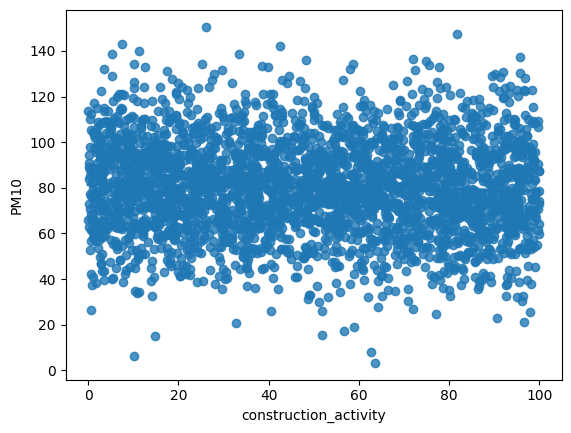

In [60]:
sns.regplot(x='construction_activity', y='PM10', data=df)

In [61]:
'''
The analysis shows an extremely weak negative correlation (-0.0388) between construction activity and PM10 levels, supported by the scatter plot which exhibits no clear pattern. This indicates that construction activity does not significantly influence PM10 concentrations in this dataset, and other factors are likely more important in determining particulate matter levels.
'''

'\nThe analysis shows an extremely weak negative correlation (-0.0388) between construction activity and PM10 levels, supported by the scatter plot which exhibits no clear pattern. This indicates that construction activity does not significantly influence PM10 concentrations in this dataset, and other factors are likely more important in determining particulate matter levels.\n'

## 5. Policy Impact

In [62]:
# 1. Did lockdown reduce AQI?
df.groupby('lockdown_status')['AQI'].mean()

lockdown_status
0    100.603426
1    100.858116
Name: AQI, dtype: float64

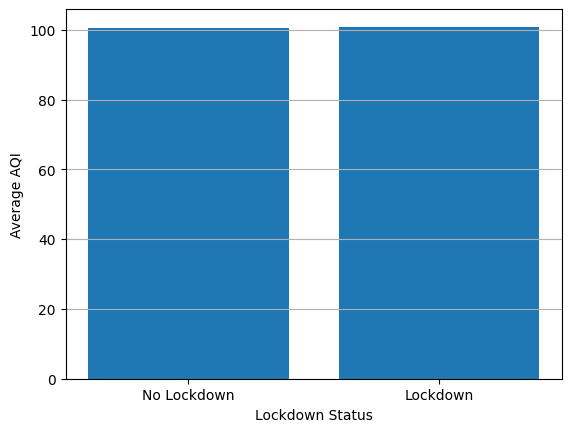

In [66]:
plt.bar(df.groupby('lockdown_status')['AQI'].mean().index, df.groupby('lockdown_status')['AQI'].mean().values)
plt.xlabel('Lockdown Status')
plt.ylabel('Average AQI')
plt.xticks(
    ticks=df.groupby('lockdown_status')['AQI'].mean().index,
    labels=['No Lockdown', 'Lockdown']
)
plt.grid(axis='y')

In [67]:
'''
The analysis shows that AQI levels are nearly the same during lockdown and non-lockdown periods, with only a marginal difference. This indicates that lockdown measures do not have a significant impact on air quality in this dataset, suggesting that other factors may play a more dominant role in influencing AQI.
'''

'\nThe analysis shows that AQI levels are nearly the same during lockdown and non-lockdown periods, with only a marginal difference. This indicates that lockdown measures do not have a significant impact on air quality in this dataset, suggesting that other factors may play a more dominant role in influencing AQI.\n'

In [69]:
# 2. Did mask usage correlate with fewer respiratory cases?
df[['mask_usage_rate', 'respiratory_admissions']].corr()


,mask_usage_rate,respiratory_admissions
mask_usage_rate,1.000000,0.012882
respiratory_admissions,0.012882,1.000000


In [70]:
'''
The correlation analysis shows an extremely weak relationship (0.0129) between mask usage rate and respiratory admissions, indicating that mask usage does not have a significant direct impact on respiratory health outcomes in this dataset.
'''

'\nThe correlation analysis shows an extremely weak relationship (0.0129) between mask usage rate and respiratory admissions, indicating that mask usage does not have a significant direct impact on respiratory health outcomes in this dataset.\n'

In [77]:
# 3. Impact of school closures on mobility and pollution?
df.groupby('school_closures')[['mobility_index', 'AQI']].mean()

,mobility_index,AQI
school_closures,,
0,80.085263,100.739464
1,79.597365,99.666290


<Axes: xlabel='school_closures', ylabel='mobility_index'>

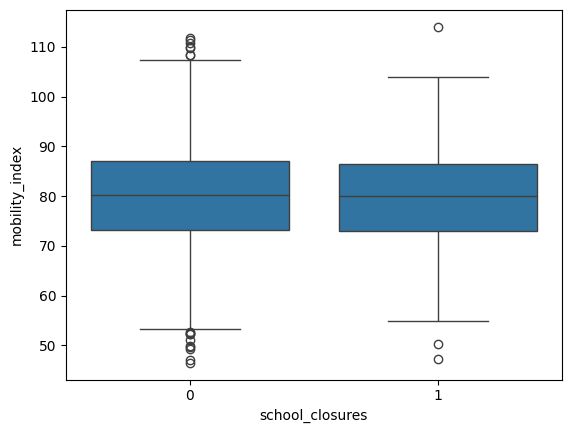

In [79]:
sns.boxplot(x='school_closures', y='mobility_index', data=df)


<Axes: xlabel='school_closures', ylabel='AQI'>

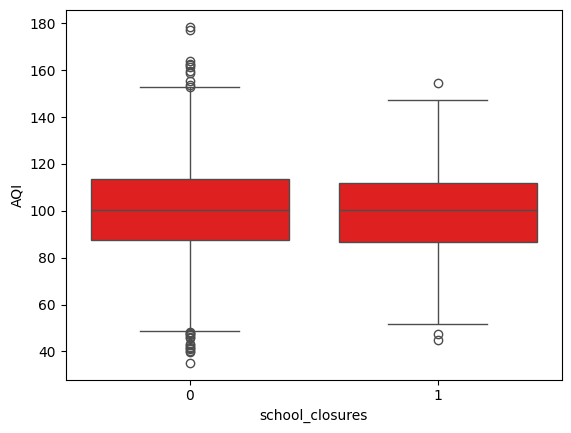

In [81]:
sns.boxplot(x='school_closures', y='AQI', data=df, color = 'red')

In [82]:
df[['school_closures', 'mobility_index', 'AQI']].corr()

,school_closures,mobility_index,AQI
school_closures,1.000000,-0.013942,-0.015770
mobility_index,-0.013942,1.000000,-0.007615
AQI,-0.015770,-0.007615,1.000000


In [83]:
'''
The analysis indicates that school closures have a negligible impact on both mobility and air quality. While there is a slight decrease in mobility and AQI during closure periods, the differences are minimal and supported by near-zero correlation values, suggesting that school closures alone do not significantly influence human movement or pollution levels in this dataset.
'''

'\nThe analysis indicates that school closures have a negligible impact on both mobility and air quality. While there is a slight decrease in mobility and AQI during closure periods, the differences are minimal and supported by near-zero correlation values, suggesting that school closures alone do not significantly influence human movement or pollution levels in this dataset.\n'

## 6. Environmental Factors

In [86]:
# 1. Does green_cover reduce AQI?
bins = [20, 40, 60, 80, 100]
labels = ['Low', 'Moderate', 'High', 'Very High']

df['green_cover_bins'] = pd.cut(df['green_cover_percentage'], bins=bins, labels=labels)

Text(0, 0.5, 'Average AQI')

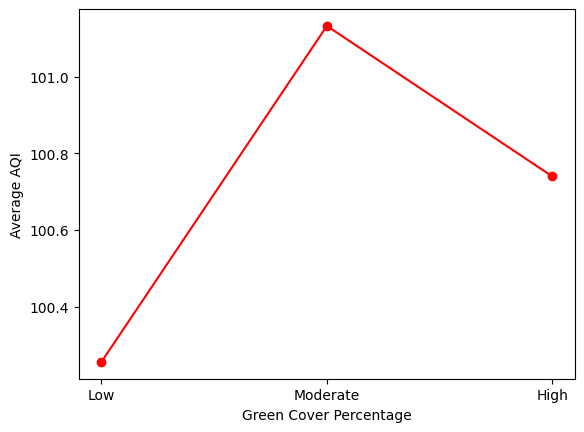

In [90]:
plt.plot(df.groupby('green_cover_bins')['AQI'].mean().index, 
df.groupby('green_cover_bins')['AQI'].mean().values, marker='o', color = 'red')
plt.xlabel('Green Cover Percentage')
plt.ylabel('Average AQI')

In [91]:
'''
The analysis shows that AQI does not consistently decrease with increasing green cover. Although areas with low green cover have slightly lower AQI, moderate and high levels do not follow a clear pattern, and the overall variation is minimal. This indicates that green cover percentage does not have a significant impact on air quality in this dataset.
'''

'\nThe analysis shows that AQI does not consistently decrease with increasing green cover. Although areas with low green cover have slightly lower AQI, moderate and high levels do not follow a clear pattern, and the overall variation is minimal. This indicates that green cover percentage does not have a significant impact on air quality in this dataset.\n'

In [96]:
# 2. Does high population_density increase pollution?
df[['population_density', 'AQI']].corr()

,population_density,AQI
population_density,1.00000,-0.01367
AQI,-0.01367,1.00000


In [102]:
bins = [0, 2000, 4000, 6000, 8000, 10000]
labels = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']

df['pop_density_level'] = pd.cut(
    df['population_density'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

<Axes: xlabel='pop_density_level', ylabel='AQI'>

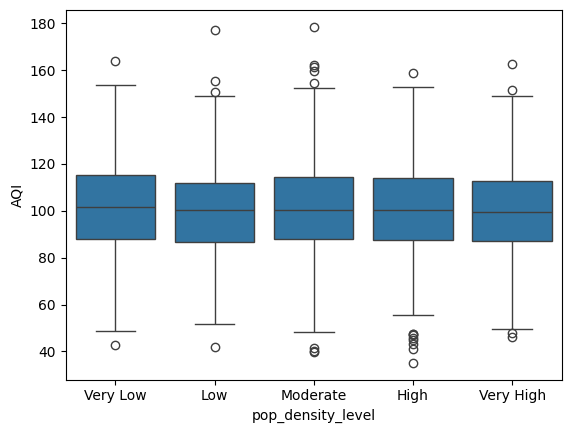

In [103]:
sns.boxplot(x='pop_density_level', y='AQI', data=df)

In [104]:
'''
The analysis shows an extremely weak correlation (-0.0137) between population density and AQI, supported by the boxplot which exhibits similar distributions across all density levels. This indicates that population density does not have a significant impact on air quality in this dataset, and AQI remains relatively consistent regardless of population concentration.
'''

'\nThe analysis shows an extremely weak correlation (-0.0137) between population density and AQI, supported by the boxplot which exhibits similar distributions across all density levels. This indicates that population density does not have a significant impact on air quality in this dataset, and AQI remains relatively consistent regardless of population concentration.\n'

## Final Observations & Project Summary

#### 1. Final Observations & Project Summary


In [105]:
'''Across the analysis, no single variable—whether pollutants (PM2.5, NO2, SO2), weather conditions (humidity, wind, rainfall), or human activities (vehicles, industry, construction)—showed a strong linear relationship with AQI. All correlation values remained close to zero, indicating that AQI is not driven by any single factor independently.'''

'Across the analysis, no single variable—whether pollutants (PM2.5, NO2, SO2), weather conditions (humidity, wind, rainfall), or human activities (vehicles, industry, construction)—showed a strong linear relationship with AQI. All correlation values remained close to zero, indicating that AQI is not driven by any single factor independently.'

#### 2. Minimal Geographic and Seasonal Variation

In [106]:
'''
Region-wise and monthly analysis showed that AQI remains relatively stable across locations and time, with only minor fluctuations. This suggests that air quality variation is not significantly influenced by geography or seasonality alone.
'''

'\nRegion-wise and monthly analysis showed that AQI remains relatively stable across locations and time, with only minor fluctuations. This suggests that air quality variation is not significantly influenced by geography or seasonality alone.\n'

#### 3. Weak Impact of Environmental and Weather Factors

In [107]:
'''
Factors such as humidity, wind speed, precipitation, and green cover did not show consistent or significant effects on pollution levels. While slight variations were observed, the overall impact remained negligible, indicating that environmental conditions alone are insufficient to explain AQI changes.
'''

'\nFactors such as humidity, wind speed, precipitation, and green cover did not show consistent or significant effects on pollution levels. While slight variations were observed, the overall impact remained negligible, indicating that environmental conditions alone are insufficient to explain AQI changes.\n'

#### 4. Limited Influence of Human Activity and Policy Measures

In [ ]:
'''
Variables such as vehicle count, industrial activity, construction activity, lockdowns, and school closures showed minimal or no measurable impact on AQI and mobility. This suggests that isolated human or policy factors do not directly translate into observable changes in air quality within this dataset.
'''

'\nVariables such as vehicle count, industrial activity, construction activity, lockdowns, and school closures showed minimal or no measurable impact on AQI and mobility. This suggests that isolated human or policy factors do not directly translate into observable changes in air quality within this dataset.\n'

#### 5. Weak Link Between Pollution and Health Outcomes

In [109]:
'''
The relationship between AQI (and pollutants) and health indicators such as hospital visits and respiratory admissions was found to be extremely weak. Even lag analysis failed to reveal any significant delayed effects. This indicates that health outcomes are likely influenced by more complex, long-term, or multi-factor interactions.
'''

'\nThe relationship between AQI (and pollutants) and health indicators such as hospital visits and respiratory admissions was found to be extremely weak. Even lag analysis failed to reveal any significant delayed effects. This indicates that health outcomes are likely influenced by more complex, long-term, or multi-factor interactions.\n'

#### 6. Evidence of a Complex, Multi-Factor System

In [110]:
'''
The consistent absence of strong relationships across all analyses suggests that air quality in this dataset behaves as a complex system influenced by multiple interacting variables, rather than simple one-to-one relationships.
'''

'\nThe consistent absence of strong relationships across all analyses suggests that air quality in this dataset behaves as a complex system influenced by multiple interacting variables, rather than simple one-to-one relationships.\n'

### Final Insight

In [111]:
'''
The key takeaway from this analysis is that air quality and its associated impacts cannot be explained through isolated variables or simple linear relationships. Instead, the system appears to be governed by complex, non-linear interactions among multiple factors.
'''

'\nThe key takeaway from this analysis is that air quality and its associated impacts cannot be explained through isolated variables or simple linear relationships. Instead, the system appears to be governed by complex, non-linear interactions among multiple factors.\n'

<h3>
The absence of strong correlations revealed that air quality is not driven by individual factors but by complex interactions, highlighting the need for multivariate modeling beyond traditional EDA.
</h3>